# PDB Homology-Leakage Re-Benchmark (10-seed, Drive-persistent & resumable)

**Runtime → Change runtime type → GPU (T4 is enough).**

All outputs are written to your Google Drive at
`/content/drive/MyDrive/Colab Notebooks/pdb_data/work/`, so if Colab disconnects
you can just re-run from the top: every expensive cell **skips work already on Drive**
- dataset build / MMseqs2 clustering: skipped if their CSV exists
- ESM-2 embeddings: checkpointed every few thousand sequences and resumed
- 10-seed ablation: each `(seed, split, model)` result is appended to Drive as it
  completes; a re-run skips everything already recorded and continues where it stopped

Raw inputs (`pdb_data_seq.csv`, `pdb_data_no_dups.csv`) are expected in
`/content/drive/MyDrive/Colab Notebooks/pdb_data/`.

## 0 · Setup + mount Drive

In [1]:
!pip install -q transformers==4.44.2 xgboost -q
import os, torch
from google.colab import drive
drive.mount('/content/drive')

DRIVE = "/content/drive/MyDrive/Colab Notebooks/pdb_data"   # raw CSVs live here
W     = f"{DRIVE}/work"                                     # all outputs persist here
SCRATCH = "/content/scratch"                                # ephemeral intermediates
os.makedirs(W, exist_ok=True)
os.makedirs(SCRATCH, exist_ok=True)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch runtime to GPU!")
print("persist dir:", W)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Mounted at /content/drive
GPU: Tesla T4
persist dir: /content/drive/MyDrive/Colab Notebooks/pdb_data/work


## 1 · Check raw data on Drive

Expects the two Kaggle CSVs in `DRIVE`. If they are missing you can upload them here
(they will be copied to Drive so this only happens once).

In [2]:
need = ["pdb_data_seq.csv", "pdb_data_no_dups.csv"]
missing = [f for f in need if not os.path.exists(f"{DRIVE}/{f}")]
if not missing:
    print("raw CSVs found in", DRIVE)
else:
    print("missing:", missing, "-> upload now (saved to Drive)")
    from google.colab import files
    up = files.upload()
    for name in up:
        os.replace(name, f"{DRIVE}/{name}")
    print("saved to", DRIVE)

raw CSVs found in /content/drive/MyDrive/Colab Notebooks/pdb_data


## 2 · Build the clean dataset  _(skipped if `dataset.csv` exists)_

Labels come from `pdb_data_no_dups.csv` only; deduplicate identical sequences; drop
conflicting-label sequences and `UNKNOWN FUNCTION` classes.

In [3]:
import pandas as pd
if os.path.exists(f"{W}/dataset.csv"):
    d = pd.read_csv(f"{W}/dataset.csv")
    print(f"[skip] dataset.csv exists -> {len(d):,} sequences")
else:
    TOP_K = 10
    DROP  = {"STRUCTURAL GENOMICS, UNKNOWN FUNCTION", "UNKNOWN FUNCTION"}
    VALID = set("ACDEFGHIKLMNPQRSTVWY")
    seq = pd.read_csv(f"{DRIVE}/pdb_data_seq.csv", low_memory=False).rename(columns={"classification": "macroType"})
    nod = pd.read_csv(f"{DRIVE}/pdb_data_no_dups.csv", low_memory=False)
    df = (seq[seq.macroType == "Protein"][["structureId", "chainId", "sequence"]]
          .merge(nod[["structureId", "classification"]], on="structureId", how="inner")
          .dropna(subset=["sequence", "classification"]))
    print(f"protein chains w/ label         : {len(df):>7,}")
    df["classification"] = df.classification.str.strip().str.upper()
    df = df[~df.classification.isin(DROP)]
    df = df[df.sequence.apply(lambda s: set(s) <= VALID)]
    df["L"] = df.sequence.str.len()
    df = df[(df.L >= 50) & (df.L <= 1000)]
    print(f"canonical-20, len 50-1000       : {len(df):>7,}")
    lab_n = df.groupby("sequence").classification.nunique()
    amb   = set(lab_n[lab_n > 1].index)
    print(f"conflicting-label sequences     : {len(amb):>7,}  (dropped)")
    df = df[~df.sequence.isin(amb)]
    d = df.drop_duplicates(subset=["sequence"]).copy()
    print(f"unique, unambiguous sequences   : {len(d):>7,}")
    top = d.classification.value_counts().head(TOP_K)
    d = d[d.classification.isin(top.index)].reset_index(drop=True)
    d["id"] = [f"s{i}" for i in range(len(d))]
    print(f"\ntop-{TOP_K} classes -> {len(d):,} sequences\n")
    print(top.to_string())
    d.to_csv(f"{W}/dataset.csv", index=False)

[skip] dataset.csv exists -> 40,211 sequences


## 3 · MMseqs2 clustering at 30% identity  _(skipped if `dataset_clustered.csv` exists)_

The MMseqs2 binary and its scratch files are written to ephemeral `/content` (fast);
only the final `dataset_clustered.csv` is persisted to Drive.

In [4]:
if os.path.exists(f"{W}/dataset_clustered.csv"):
    d = pd.read_csv(f"{W}/dataset_clustered.csv")
    print(f"[skip] dataset_clustered.csv exists -> {d.cluster.nunique():,} clusters")
else:
    if "d" not in globals():
        d = pd.read_csv(f"{W}/dataset.csv")
    %cd /content/scratch
    !wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz && tar xzf mmseqs-linux-avx2.tar.gz
    MM = "/content/scratch/mmseqs/bin/mmseqs"
    with open(f"{SCRATCH}/seqs.fasta", "w") as f:
        for i, s in zip(d.id, d.sequence):
            f.write(f">{i}\n{s}\n")
    !{MM} easy-cluster {SCRATCH}/seqs.fasta {SCRATCH}/clu {SCRATCH}/tmp \
        --min-seq-id 0.3 -c 0.8 --cov-mode 1 --cluster-mode 0 -v 1
    clu = pd.read_csv(f"{SCRATCH}/clu_cluster.tsv", sep="\t", header=None, names=["rep", "member"])
    d["cluster"] = d.id.map(dict(zip(clu.member, clu.rep)))
    assert d.cluster.notna().all()
    sizes = d.cluster.value_counts()
    print(f"\nclusters        : {len(sizes):,}")
    print(f"largest cluster : {sizes.iloc[0]:,}  ({100*sizes.iloc[0]/len(d):.1f}% of data)")
    print(f"singletons      : {(sizes == 1).sum():,}")
    d.to_csv(f"{W}/dataset_clustered.csv", index=False)

[skip] dataset_clustered.csv exists -> 9,533 clusters


## 4 · ESM-2 650M frozen embeddings  _(checkpointed & resumable)_

Frozen mean-pooled representation, seed-independent, computed once. The partial
embedding matrix is check-pointed to Drive every `CKPT_EVERY` sequences; if the runtime
dies, re-running this cell resumes from the last checkpoint instead of restarting.

In [5]:
import numpy as np
EMB  = f"{W}/esm2_embeddings.npy"
CKPT = f"{W}/esm2_embeddings_ckpt.npz"
if "d" not in globals():
    d = pd.read_csv(f"{W}/dataset_clustered.csv")

if os.path.exists(EMB):
    X = np.load(EMB)
    print(f"[skip] embeddings exist -> {X.shape}")
else:
    from transformers import EsmModel, EsmTokenizer
    MODEL  = "facebook/esm2_t33_650M_UR50D"   # -> esm2_t12_35M_UR50D for a fast pass
    MAXLEN, BATCH, CKPT_EVERY = 1022, 8, 8000
    dev = "cuda"
    tok = EsmTokenizer.from_pretrained(MODEL)
    esm = EsmModel.from_pretrained(MODEL).to(dev).eval().half()
    H = esm.config.hidden_size
    order = np.argsort(d.L.values)            # deterministic -> safe to resume
    seqs  = d.sequence.values
    if os.path.exists(CKPT):
        z = np.load(CKPT); X = z["X"]; start = int(z["n_done"])
        print(f"[resume] from {start:,}/{len(order):,}")
    else:
        X = np.zeros((len(d), H), dtype=np.float32); start = 0
    with torch.no_grad():
        for i in range(start, len(order), BATCH):
            sel   = order[i:i+BATCH]
            batch = [seqs[j][:MAXLEN] for j in sel]
            enc   = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAXLEN).to(dev)
            out   = esm(**enc).last_hidden_state
            mask  = enc["attention_mask"].unsqueeze(-1).to(out.dtype).clone()
            mask[:, 0] = 0
            pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
            X[sel] = pooled.float().cpu().numpy()
            if i > 0 and i % CKPT_EVERY < BATCH:
                np.savez(CKPT, X=X, n_done=i + BATCH)
                print(f"  ckpt {min(i+BATCH, len(order)):,}/{len(order):,}", flush=True)
    np.save(EMB, X)
    if os.path.exists(CKPT):
        os.remove(CKPT)
    print("embeddings:", X.shape)

[skip] embeddings exist -> (40211, 1280)


## 5 · Ten-seed ablation  _(row-level resume from Drive)_

For seeds 0–9 and both splits, evaluate the four models on identical folds. Each
`(seed, split, model)` result is appended to `results_10seed.csv` on Drive the moment
it finishes, and a set of already-completed cells is loaded at startup — so an
interrupted run resumes exactly where it stopped, recomputing nothing already saved.

In [6]:
import time, gc
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn import config_context
import warnings; warnings.filterwarnings("ignore")

SEEDS = list(range(10))
RES   = f"{W}/results_10seed.csv"
ESM_NAME = "ESM-2 650M frozen + linear probe"

d      = pd.read_csv(f"{W}/dataset_clustered.csv")
X      = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
y      = d.classification.values
idx    = np.arange(len(d))
groups = d.cluster.values
kmers  = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in d.sequence.values])

if os.path.exists(RES):
    done = set(map(tuple, pd.read_csv(RES)[["seed","split","model"]].values))
    print(f"[resume] {len(done)} result rows already on Drive")
else:
    pd.DataFrame(columns=["seed","split","model","acc","macro_f1"]).to_csv(RES, index=False)
    done = set()

def add(**r):
    pd.DataFrame([r]).to_csv(RES, mode="a", header=False, index=False)

KMER_MODELS = {
    "1-NN (memorisation probe)": lambda: KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute"),
    "Logistic Regression":       lambda: LogisticRegression(max_iter=1000),
    "Linear SVM":                lambda: LinearSVC(C=0.5, max_iter=3000),
}

t0 = time.time()
for seed in SEEDS:
    tr_r, te_r = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_c, te_c = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
    splits = {"random": (tr_r, te_r), "cluster": (tr_c, te_c)}
    for split, (tr, te) in splits.items():
        need_kmer = [n for n in KMER_MODELS if (seed, split, n) not in done]
        need_esm  = (seed, split, ESM_NAME) not in done
        if not need_kmer and not need_esm:
            print(f"seed={seed} {split:7s} [skip, done]", flush=True); continue
        print(f"seed={seed} {split:7s} train={len(tr):,} test={len(te):,} "
              f"todo={need_kmer + ([ESM_NAME] if need_esm else [])}", flush=True)
        if need_kmer:
            vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
            Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
            for name in need_kmer:
                with config_context(working_memory=256):
                    p = KMER_MODELS[name]().fit(Xtr, y[tr]).predict(Xte)
                add(seed=seed, split=split, model=name,
                    acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"))
                done.add((seed, split, name))
            del Xtr, Xte, vec; gc.collect()
        if need_esm:
            sc  = StandardScaler().fit(X[tr])
            clf = LogisticRegression(max_iter=3000).fit(sc.transform(X[tr]).astype(np.float32), y[tr])
            p   = clf.predict(sc.transform(X[te]).astype(np.float32))
            add(seed=seed, split=split, model=ESM_NAME,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"))
            done.add((seed, split, ESM_NAME))

res = pd.read_csv(RES)
print(f"\ndone in {(time.time()-t0)/60:.1f} min  ->  {len(res)} rows on Drive")

[resume] 80 result rows already on Drive
seed=0 random  [skip, done]
seed=0 cluster [skip, done]
seed=1 random  [skip, done]
seed=1 cluster [skip, done]
seed=2 random  [skip, done]
seed=2 cluster [skip, done]
seed=3 random  [skip, done]
seed=3 cluster [skip, done]
seed=4 random  [skip, done]
seed=4 cluster [skip, done]
seed=5 random  [skip, done]
seed=5 cluster [skip, done]
seed=6 random  [skip, done]
seed=6 cluster [skip, done]
seed=7 random  [skip, done]
seed=7 cluster [skip, done]
seed=8 random  [skip, done]
seed=8 cluster [skip, done]
seed=9 random  [skip, done]
seed=9 cluster [skip, done]

done in 0.0 min  ->  80 rows on Drive


## 6 · Leakage exposure (model-free)

How much homology leaks into a random split, measured **directly from the cluster assignments** without training any classifier. Reproduces the manuscript's leakage-exposure statistics (fraction of random-split test sequences that already have a $\geq$30% identity homolog in training).

In [7]:
# Fraction of RANDOM-split test sequences that share an MMseqs2 cluster (>=30% id,
# 80% cov) with at least one training sequence -> they have a near-homolog in train.
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

d = pd.read_csv(f"{W}/dataset_clustered.csv")
y = d.classification.values
idx = np.arange(len(d))
groups = d.cluster.values
SEEDS = list(range(10))

leaked, depth = [], []
for seed in SEEDS:
    tr, te = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_clusters = set(groups[tr])
    trc = Counter(groups[tr])
    te_g = groups[te]
    exposed = np.isin(te_g, list(tr_clusters))
    leaked.append(100.0 * exposed.mean())
    depth.append(np.mean([trc[c] for c in te_g if c in tr_clusters]))
leaked = np.array(leaked); depth = np.array(depth)

csize = pd.Series(groups).value_counts()
singleton_seq_pct = 100.0 * (csize[groups].values == 1).mean()

print(f"Random-split test sequences with a >=30% identity homolog in train : {leaked.mean():.1f}% ± {leaked.std():.1f}%")
print(f"Mean same-cluster training neighbours per exposed test sequence      : {depth.mean():.0f}")
print(f"Sequences in singleton clusters (no homolog anywhere in the data)    : {singleton_seq_pct:.1f}%")

pd.DataFrame({"seed": SEEDS, "leaked_pct": leaked, "mean_neighbours": depth}).to_csv(
    f"{W}/leakage_exposure.csv", index=False)

Random-split test sequences with a >=30% identity homolog in train : 86.5% ± 0.3%
Mean same-cluster training neighbours per exposed test sequence      : 118
Sequences in singleton clusters (no homolog anywhere in the data)    : 11.5%


## 6b · Threshold sweep — sensitivity to the identity cut (reviewer M2)

Re-clusters the sequences with MMseqs2 at a range of minimum identities and repeats the leakage-free evaluation at each, tracing performance vs. threshold. Uses the MMseqs2 binary from Section 3 and the cached embeddings from Section 4. Resumable: results append to `sweep_results.csv` and completed (threshold, seed, model) cells are skipped. This is the slow cell (several re-clusterings + 10 seeds each).

> **If you hit `OSError: [Errno 107] Transport endpoint is not connected`** the Drive mount dropped. Remount with `drive.flush_and_unmount(); drive.mount('/content/drive')` (or Runtime → Restart runtime, then re-run Section 0) and run this cell again — inputs are cached locally so it resumes quickly.

In [8]:
import numpy as np, pandas as pd, os, subprocess
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn import config_context
import warnings; warnings.filterwarnings("ignore")

THRESHOLDS = [0.9, 0.7, 0.5, 0.4, 0.3, 0.2]
SEEDS = list(range(10))
SWEEP = f"{W}/sweep_results.csv"
MM = "/content/scratch/mmseqs/bin/mmseqs"
# Section 3 skips the MMseqs2 download when dataset_clustered.csv already exists, and a
# runtime restart wipes /content. Re-download the binary here if it is missing.
if not os.path.exists(MM):
    os.makedirs(SCRATCH, exist_ok=True)
    print("mmseqs binary not found - downloading ...", flush=True)
    subprocess.run(f"cd {SCRATCH} && wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz "
                   f"&& tar xzf mmseqs-linux-avx2.tar.gz", shell=True, check=True)
assert os.path.exists(MM), "mmseqs still missing after download - check network / CPU (avx2 build)."

# Cache large inputs on LOCAL disk first. Reading the 200 MB embeddings repeatedly
# from Drive during this long cell can drop the FUSE mount ("Transport endpoint is
# not connected"); copying once to /content avoids that and is much faster.
import shutil
LOCAL = "/content/local_cache"; os.makedirs(LOCAL, exist_ok=True)
for fn in ["dataset_clustered.csv", "esm2_embeddings.npy"]:
    src_p, dst_p = f"{W}/{fn}", f"{LOCAL}/{fn}"
    if (not os.path.exists(dst_p)) or (os.path.getsize(dst_p) != os.path.getsize(src_p)):
        shutil.copy(src_p, dst_p)

d0 = pd.read_csv(f"{LOCAL}/dataset_clustered.csv")   # same row order as the cached embeddings
y = d0.classification.values
idx = np.arange(len(d0))
X = np.load(f"{LOCAL}/esm2_embeddings.npy").astype(np.float32)
assert X.shape[0] == len(d0), (
    f"embeddings rows ({X.shape[0]}) != sequences ({len(d0)}); the .npy read is "
    "incomplete or stale. If you saw 'Transport endpoint is not connected', remount "
    "Drive (Section 0) and re-run this cell; otherwise re-run Section 4 to rebuild embeddings.")
kmers = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in d0.sequence.values])

fasta = f"{LOCAL}/seqs.fasta"
if not os.path.exists(fasta):
    with open(fasta, "w") as f:
        for i, s in zip(d0.id, d0.sequence):
            f.write(f">{i}\n{s}\n")

KMER = {
    "1-NN (memorisation probe)": lambda: KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute"),
    "Logistic Regression":       lambda: LogisticRegression(max_iter=1000),
    "Linear SVM":                lambda: LinearSVC(C=0.5, max_iter=3000),
}
ESM_NAME = "ESM-2 650M frozen + linear probe"
ALL_MODELS = list(KMER) + [ESM_NAME]

if os.path.exists(SWEEP):
    done = set(map(tuple, pd.read_csv(SWEEP)[["threshold","seed","model"]].values))
else:
    pd.DataFrame(columns=["threshold","seed","split","model","acc","macro_f1","n_clusters"]).to_csv(SWEEP, index=False)
    done = set()
def add(**r): pd.DataFrame([r]).to_csv(SWEEP, mode="a", header=False, index=False)

def cluster_at(tid):
    pref = f"{SCRATCH}/clu_{int(round(tid*100))}"
    subprocess.run(f"{MM} easy-cluster {fasta} {pref} {SCRATCH}/tmp_{int(round(tid*100))} "
                   f"--min-seq-id {tid} -c 0.8 --cov-mode 1 --cluster-mode 0 -v 1",
                   shell=True, check=True)
    clu = pd.read_csv(f"{pref}_cluster.tsv", sep="\t", header=None, names=["rep","member"])
    return d0.id.map(dict(zip(clu.member, clu.rep))).values

for tid in THRESHOLDS:
    if all((tid, s, m) in done for s in SEEDS for m in ALL_MODELS):
        print(f"[skip] identity {tid} already complete"); continue
    print(f"=== clustering at min-seq-id {tid} ===", flush=True)
    groups = cluster_at(tid); nC = len(set(groups))
    print(f"    {nC:,} clusters", flush=True)
    for seed in SEEDS:
        tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=seed).split(idx, y, groups=groups))
        need_k = [m for m in KMER if (tid, seed, m) not in done]
        if need_k:
            vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
            Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
            for m in need_k:
                with config_context(working_memory=256):
                    p = KMER[m]().fit(Xtr, y[tr]).predict(Xte)
                add(threshold=tid, seed=seed, split="cluster", model=m,
                    acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
            del Xtr, Xte, vec
        if (tid, seed, ESM_NAME) not in done:
            sc = StandardScaler().fit(X[tr])
            clf = LogisticRegression(max_iter=3000).fit(sc.transform(X[tr]).astype(np.float32), y[tr])
            p = clf.predict(sc.transform(X[te]).astype(np.float32))
            add(threshold=tid, seed=seed, split="cluster", model=ESM_NAME,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
    print(f"    identity {tid} done", flush=True)
print("sweep complete ->", SWEEP)

mmseqs binary not found - downloading ...
[skip] identity 0.9 already complete
[skip] identity 0.7 already complete
[skip] identity 0.5 already complete
[skip] identity 0.4 already complete
[skip] identity 0.3 already complete
=== clustering at min-seq-id 0.2 ===
    7,755 clusters
    identity 0.2 done
sweep complete -> /content/drive/MyDrive/Colab Notebooks/pdb_data/work/sweep_results.csv


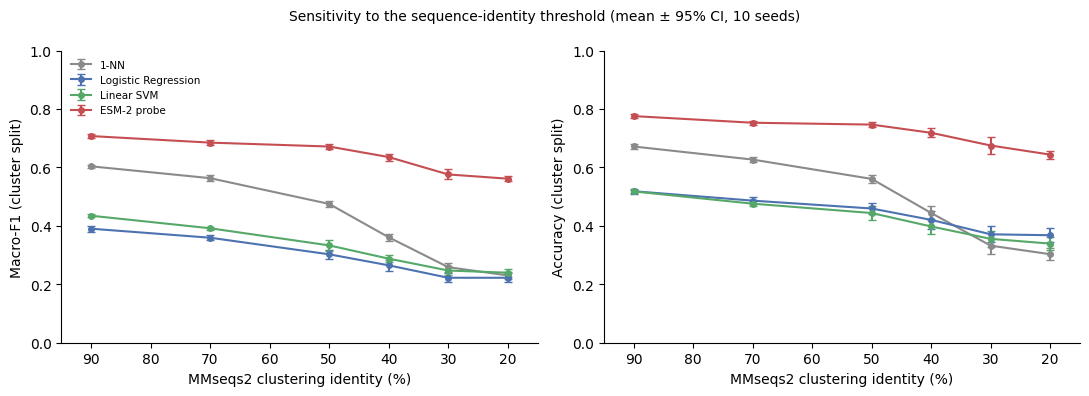

macro-F1 by threshold:

threshold                           0.2    0.3    0.4    0.5    0.7    0.9
model                                                                     
1-NN (memorisation probe)         0.230  0.259  0.361  0.475  0.563  0.604
ESM-2 650M frozen + linear probe  0.561  0.576  0.635  0.671  0.685  0.707
Linear SVM                        0.240  0.247  0.288  0.333  0.392  0.435
Logistic Regression               0.222  0.222  0.265  0.303  0.359  0.390


In [9]:
import matplotlib.pyplot as plt
sw = pd.read_csv(f"{W}/sweep_results.csv")
ORDER = ["1-NN (memorisation probe)", "Logistic Regression", "Linear SVM", ESM_NAME]
COL = {"1-NN (memorisation probe)":"#8a8a8a", "Logistic Regression":"#4C72B0",
       "Linear SVM":"#55A868", ESM_NAME:"#C44E52"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, met, lab in zip(axes, ["macro_f1", "acc"], ["Macro-F1", "Accuracy"]):
    for m in ORDER:
        g = sw[sw.model==m].groupby("threshold")[met].agg(["mean","std","count"]).sort_index()
        thr = g.index.values*100
        half = 1.96*g["std"].values/np.sqrt(g["count"].values)
        label = "ESM-2 probe" if m==ESM_NAME else m.split(" (")[0]
        ax.errorbar(thr, g["mean"].values, yerr=half, marker="o", ms=4, capsize=3, label=label, color=COL[m])
    ax.set_xlabel("MMseqs2 clustering identity (%)"); ax.set_ylabel(f"{lab} (cluster split)")
    ax.set_xlim(95, 15); ax.set_ylim(0, 1); ax.spines[["top","right"]].set_visible(False)
axes[0].legend(fontsize=7.5, frameon=False, loc="upper left")
fig.suptitle("Sensitivity to the sequence-identity threshold (mean ± 95% CI, 10 seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_threshold_sweep.png", dpi=300, bbox_inches="tight"); plt.show()
print("macro-F1 by threshold:\n")
print(sw.groupby(["model","threshold"]).macro_f1.mean().unstack().round(3).to_string())

## 7 · Aggregate — mean ± s.d. and 95% CI

In [10]:
res = pd.read_csv(f"{W}/results_10seed.csv")
ORDER = ["1-NN (memorisation probe)", "Logistic Regression", "Linear SVM", ESM_NAME]
agg = (res.groupby(["model", "split"])
          .agg(acc_mean=("acc","mean"), acc_std=("acc","std"),
               f1_mean=("macro_f1","mean"), f1_std=("macro_f1","std"))
          .round(4).reset_index())
agg.to_csv(f"{W}/results_10seed_summary.csv", index=False)
n_seeds = res.seed.nunique()

print(f"Macro-F1  (mean ± s.d. over {n_seeds} seeds)\n")
for m in ORDER:
    r_ = agg[(agg.model==m) & (agg.split=="random")].iloc[0]
    c_ = agg[(agg.model==m) & (agg.split=="cluster")].iloc[0]
    drop = 100 * (c_.f1_mean - r_.f1_mean) / r_.f1_mean
    print(f"  {m:34s} random {r_.f1_mean:.3f}±{r_.f1_std:.3f}   cluster {c_.f1_mean:.3f}±{c_.f1_std:.3f}   ({drop:+.0f}%)")

print(f"\nAccuracy  (mean ± s.d. over {n_seeds} seeds)\n")
for m in ORDER:
    r_ = agg[(agg.model==m) & (agg.split=="random")].iloc[0]
    c_ = agg[(agg.model==m) & (agg.split=="cluster")].iloc[0]
    drop = 100 * (c_.acc_mean - r_.acc_mean) / r_.acc_mean
    print(f"  {m:34s} random {r_.acc_mean:.3f}±{r_.acc_std:.3f}   cluster {c_.acc_mean:.3f}±{c_.acc_std:.3f}   ({drop:+.0f}%)")

# --- 95% confidence intervals on the leakage-free cluster split (both metrics) ---
import numpy as np
from scipy import stats
def ci95(x):
    x = np.asarray(x); m = x.mean()
    half = stats.t.ppf(0.975, len(x)-1) * x.std(ddof=1) / (len(x) ** 0.5)
    return m, m - half, m + half

ci_rows = []
for metric, col in [("macro_f1", "macro_f1"), ("accuracy", "acc")]:
    for m in ORDER:
        mean, lo, hi = ci95(res[(res.model==m) & (res.split=="cluster")][col].values)
        ci_rows.append(dict(model=m, metric=metric, split="cluster",
                            mean=round(mean,4), ci_low=round(lo,4), ci_high=round(hi,4)))
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(f"{W}/results_10seed_ci.csv", index=False)

print(f"\n95% CI for cluster-split Macro-F1 (t-based, {n_seeds} seeds)\n")
for m in ORDER:
    r_ = ci_df[(ci_df.model==m) & (ci_df.metric=="macro_f1")].iloc[0]
    print(f"  {m:34s} {r_['mean']:.3f}  [{r_['ci_low']:.3f}, {r_['ci_high']:.3f}]")

print(f"\n95% CI for cluster-split Accuracy (t-based, {n_seeds} seeds)\n")
for m in ORDER:
    r_ = ci_df[(ci_df.model==m) & (ci_df.metric=="accuracy")].iloc[0]
    print(f"  {m:34s} {r_['mean']:.3f}  [{r_['ci_low']:.3f}, {r_['ci_high']:.3f}]")

Macro-F1  (mean ± s.d. over 10 seeds)

  1-NN (memorisation probe)          random 0.770±0.006   cluster 0.259±0.024   (-66%)
  Logistic Regression                random 0.602±0.007   cluster 0.222±0.024   (-63%)
  Linear SVM                         random 0.666±0.007   cluster 0.247±0.023   (-63%)
  ESM-2 650M frozen + linear probe   random 0.797±0.007   cluster 0.576±0.028   (-28%)

Accuracy  (mean ± s.d. over 10 seeds)

  1-NN (memorisation probe)          random 0.811±0.004   cluster 0.332±0.044   (-59%)
  Logistic Regression                random 0.667±0.006   cluster 0.371±0.044   (-44%)
  Linear SVM                         random 0.706±0.005   cluster 0.355±0.046   (-50%)
  ESM-2 650M frozen + linear probe   random 0.844±0.005   cluster 0.675±0.045   (-20%)

95% CI for cluster-split Macro-F1 (t-based, 10 seeds)

  1-NN (memorisation probe)          0.259  [0.241, 0.276]
  Logistic Regression                0.222  [0.205, 0.240]
  Linear SVM                         0.247  [0.231,

## 8 · Figures — comparison bars (mean ± s.d.) and cluster-split 95% CI

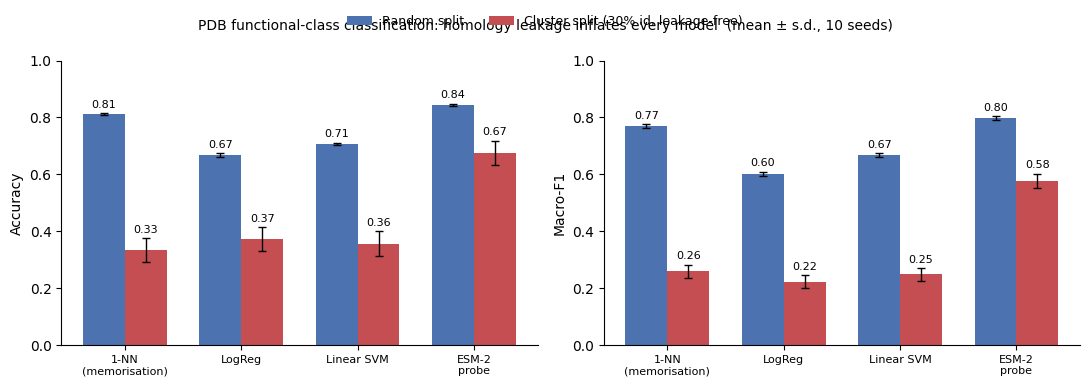

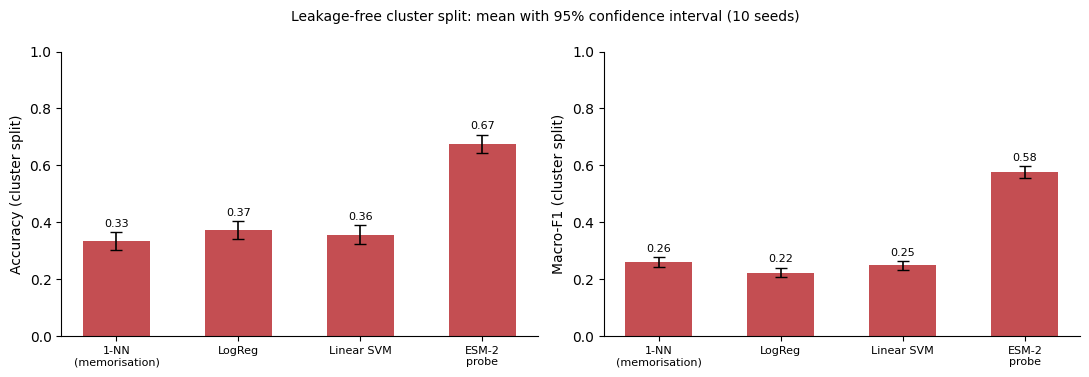

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
res = pd.read_csv(f"{W}/results_10seed.csv")
LABELS = ["1-NN\n(memorisation)", "LogReg", "Linear SVM", "ESM-2\nprobe"]

def ms(m, sp, met):
    v = res[(res.model==m) & (res.split==sp)][met].values
    return v.mean(), v.std()

# --- Figure 1: random vs cluster, mean ± s.d. ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, met, lab in zip(axes, ["acc", "macro_f1"], ["Accuracy", "Macro-F1"]):
    rm, rs = zip(*[ms(m, "random",  met) for m in ORDER])
    cm, cs = zip(*[ms(m, "cluster", met) for m in ORDER])
    x, w = np.arange(len(ORDER)), 0.36
    ax.bar(x - w/2, rm, w, yerr=rs, capsize=3, label="Random split", color="#4C72B0", error_kw=dict(lw=1))
    ax.bar(x + w/2, cm, w, yerr=cs, capsize=3, label="Cluster split (30% id, leakage-free)", color="#C44E52", error_kw=dict(lw=1))
    for i, (v, s) in enumerate(zip(rm, rs)): ax.text(i - w/2, v + s + .02, f"{v:.2f}", ha="center", fontsize=8)
    for i, (v, s) in enumerate(zip(cm, cs)): ax.text(i + w/2, v + s + .02, f"{v:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylabel(lab); ax.set_ylim(0, 1.0); ax.spines[["top", "right"]].set_visible(False)
fig.legend(labels=["Random split","Cluster split (30% id, leakage-free)"], loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"PDB functional-class classification: homology leakage inflates every model  (mean ± s.d., {res.seed.nunique()} seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_figure_10seed.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Figure 2: leakage-free cluster split, mean with 95% CI (Accuracy and Macro-F1) ---
def ci_half(x):
    x = np.asarray(x)
    return x.mean(), stats.t.ppf(0.975, len(x)-1) * x.std(ddof=1) / (len(x) ** 0.5)

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, met, lab in zip(axes2, ["acc", "macro_f1"], ["Accuracy", "Macro-F1"]):
    means, halves = zip(*[ci_half(res[(res.model==m) & (res.split=="cluster")][met].values) for m in ORDER])
    x = np.arange(len(ORDER))
    ax.bar(x, means, 0.55, yerr=halves, capsize=4, color="#C44E52", error_kw=dict(lw=1.2))
    for i, (mn, h) in enumerate(zip(means, halves)):
        ax.text(i, mn + h + .02, f"{mn:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylabel(f"{lab} (cluster split)"); ax.set_ylim(0, 1.0); ax.spines[["top", "right"]].set_visible(False)
fig2.suptitle(f"Leakage-free cluster split: mean with 95% confidence interval ({res.seed.nunique()} seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_ci_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

## 9 · Paired tests — ESM-2 vs all baselines (95% CI and effect size)

Reproduces the manuscript's paired comparison table on the leakage-free split, with 95% confidence intervals, paired $t$/Wilcoxon $p$-values, and paired Cohen $d_z$ effect sizes.

In [12]:
import numpy as np
from scipy import stats
res = pd.read_csv(f"{W}/results_10seed.csv")
n = res.seed.nunique()
BASELINES = ["Logistic Regression", "Linear SVM", "1-NN (memorisation probe)"]

def paired_table(metric):
    piv = res[res.split=="cluster"].pivot(index="seed", columns="model", values=metric)
    esm = piv[ESM_NAME].values
    rows = []
    for base in BASELINES:
        b = piv[base].values
        diff = esm - b
        m, sd = diff.mean(), diff.std(ddof=1)
        half = stats.t.ppf(0.975, n-1) * sd / (n ** 0.5)
        t, p = stats.ttest_rel(esm, b)
        dz = m / sd
        w = stats.wilcoxon(esm, b)
        rows.append(dict(metric=metric, baseline=base, gap=round(m,4), gap_sd=round(sd,4),
                         ci_low=round(m-half,4), ci_high=round(m+half,4),
                         t=round(t,2), p=p, cohen_dz=round(dz,2), wilcoxon_p=round(w.pvalue,4)))
    return pd.DataFrame(rows)

tables = []
for metric, name in [("macro_f1", "Macro-F1"), ("acc", "Accuracy")]:
    tbl = paired_table(metric)
    tables.append(tbl)
    print(f"ESM-2 vs baselines on the leakage-free cluster split ({name}, paired, n={n})\n")
    print(f"  {'baseline':26s} {'gap ± sd':>14s} {'95% CI':>18s} {'t':>7s} {'p':>10s} {'d_z':>6s} {'Wilcoxon':>9s}")
    for _, r in tbl.iterrows():
        print(f"  {r['baseline']:26s} {r['gap']:.3f} ± {r['gap_sd']:.3f}  [{r['ci_low']:.3f}, {r['ci_high']:.3f}]  {r['t']:6.1f} {r['p']:10.2e} {r['cohen_dz']:6.1f} {r['wilcoxon_p']:9.4f}")
    print()

paired_df = pd.concat(tables, ignore_index=True)
paired_df.to_csv(f"{W}/results_10seed_paired.csv", index=False)
print("saved -> results_10seed_paired.csv")

ESM-2 vs baselines on the leakage-free cluster split (Macro-F1, paired, n=10)

  baseline                         gap ± sd             95% CI       t          p    d_z  Wilcoxon
  Logistic Regression        0.354 ± 0.019  [0.340, 0.367]    57.5   7.30e-13   18.2    0.0020
  Linear SVM                 0.329 ± 0.025  [0.311, 0.347]    41.2   1.44e-11   13.1    0.0020
  1-NN (memorisation probe)  0.317 ± 0.030  [0.296, 0.339]    33.8   8.65e-11   10.7    0.0020

ESM-2 vs baselines on the leakage-free cluster split (Accuracy, paired, n=10)

  baseline                         gap ± sd             95% CI       t          p    d_z  Wilcoxon
  Logistic Regression        0.304 ± 0.040  [0.276, 0.332]    24.3   1.61e-09    7.7    0.0020
  Linear SVM                 0.320 ± 0.037  [0.293, 0.346]    27.0   6.31e-10    8.5    0.0020
  1-NN (memorisation probe)  0.343 ± 0.044  [0.311, 0.374]    24.7   1.40e-09    7.8    0.0020

saved -> results_10seed_paired.csv


## 10 · Save all result outputs and bundle

In [13]:
import shutil
# every persisted result output from this study
arts = [
    "dataset_clustered.csv",         # curated dataset + 30% identity clusters
    "results_10seed.csv",            # per-seed raw metrics (accuracy + macro-F1)
    "results_10seed_summary.csv",    # mean/std per model and split
    "results_10seed_ci.csv",         # 95% CI, cluster split (accuracy + macro-F1)
    "results_10seed_paired.csv",     # paired ESM-2 vs baselines (accuracy + macro-F1)
    "leakage_exposure.csv",          # model-free leakage exposure
    "leakage_figure_10seed.png",     # random vs cluster bars (accuracy + macro-F1)
    "leakage_ci_cluster.png",
    "sweep_results.csv",
    "leakage_threshold_sweep.png",        # cluster-split 95% CI plot (accuracy + macro-F1)
]
os.makedirs(f"{SCRATCH}/bundle", exist_ok=True)
saved = []
for a in arts:
    p = f"{W}/{a}"
    if os.path.exists(p):
        shutil.copy(p, f"{SCRATCH}/bundle/{a}"); saved.append(a)
    else:
        print(f"[warn] missing (run its section first): {a}")

# final cluster-split summary including accuracy
res = pd.read_csv(f"{W}/results_10seed.csv")
ORDER = ["1-NN (memorisation probe)", "Logistic Regression", "Linear SVM", ESM_NAME]
print("\nFinal leakage-free (cluster split) summary — mean over seeds:")
print(f"  {'model':34s} {'Accuracy':>10s} {'Macro-F1':>10s}")
for m in ORDER:
    a = res[(res.model==m) & (res.split=="cluster")].acc.mean()
    f = res[(res.model==m) & (res.split=="cluster")].macro_f1.mean()
    print(f"  {m:34s} {a:10.3f} {f:10.3f}")

shutil.make_archive(f"{SCRATCH}/results_10seed_bundle", "zip", f"{SCRATCH}/bundle")
print(f"\nbundled {len(saved)} files -> results_10seed_bundle.zip")
from google.colab import files
files.download(f"{SCRATCH}/results_10seed_bundle.zip")


Final leakage-free (cluster split) summary — mean over seeds:
  model                                Accuracy   Macro-F1
  1-NN (memorisation probe)               0.332      0.259
  Logistic Regression                     0.371      0.222
  Linear SVM                              0.355      0.247
  ESM-2 650M frozen + linear probe        0.675      0.576

bundled 10 files -> results_10seed_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>